# Final project: Time-series data and application to stock markets {-}

This project aims at familiarizing you with time-series data analysis and its application to stock markets. Datasets you will be working on are Nasdaq and Vietnam stock datasets.

### Submission {-}
The structure of submission folder should be organized as follows:

- ./\<StudentID>-project-notebook.ipynb: Jupyter notebook containing source code.
- ./\<StudentID>-project-report.pdf: project report.

The submission folder is named DL4AI-\<StudentID>-project (e.g., DL4AI-2012345-project) and then compressed with the same name.
    
### Evaluation {-}
Project evaluation will be conducted on how you accomplish the assignment requirements. You can refer to the project instruction slide deck for details.

### Deadline {-}
Please visit Canvas for details.

## Task 1 - Nasdaq stock price prediction (Nasdaq dataset)

### Task 1.1 Nasdaq multi-feature extension

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('csv/AAPL.csv')

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

df.head()

,Low,Open,Volume,High,Close,Adjusted Close
Date,,,,,,
1980-12-12,0.128348,0.128348,469033600,0.128906,0.128348,0.099874
1980-12-15,0.121652,0.122210,175884800,0.122210,0.121652,0.094663
1980-12-16,0.112723,0.113281,105728000,0.113281,0.112723,0.087715
1980-12-17,0.115513,0.115513,86441600,0.116071,0.115513,0.089886
1980-12-18,0.118862,0.118862,73449600,0.119420,0.118862,0.092492


In [3]:
features = ['Open', 'High', 'Low', 'Close', 'Adjusted Close', 'Volume']

In [4]:
X_data = df[features].values
y_data = df[['Close']].values  # target = Close only

In [5]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X_data)
y_scaled = scaler_y.fit_transform(y_data)

In [6]:
time_steps = 60

X = []
y = []

for i in range(time_steps, len(X_scaled)):
    X.append(X_scaled[i-time_steps:i])
    y.append(y_scaled[i])

X = np.array(X)
y = np.array(y)

print(X.shape)  # (samples, 60, 6)
print(y.shape)  # (samples, 1)

(10530, 60, 6)
(10530, 1)


In [7]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
y_train = y[:train_size]

X_test = X[train_size:]
y_test = y[train_size:]

In [8]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X.shape[1], X.shape[2])),
    LSTM(32),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 60, 64)            18176     
                                                                 
 lstm_1 (LSTM)               (None, 32)                12416     
                                                                 
 dense (Dense)               (None, 1)                 33        
                                                                 
Total params: 30625 (119.63 KB)
Trainable params: 30625 (119.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [9]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
264/264 [==============================] - 8s 24ms/step - loss: 1.8969e-05 - val_loss: 0.0054
Epoch 2/10
264/264 [==============================] - 6s 24ms/step - loss: 2.6759e-06 - val_loss: 0.0048
Epoch 3/10
264/264 [==============================] - 6s 23ms/step - loss: 2.3571e-06 - val_loss: 0.0048
Epoch 4/10
264/264 [==============================] - 6s 24ms/step - loss: 2.4111e-06 - val_loss: 0.0058
Epoch 5/10
264/264 [==============================] - 6s 23ms/step - loss: 2.1907e-06 - val_loss: 0.0032
Epoch 6/10
264/264 [==============================] - 6s 21ms/step - loss: 1.8933e-06 - val_loss: 0.0029
Epoch 7/10
264/264 [==============================] - 6s 23ms/step - loss: 1.9507e-06 - val_loss: 0.0037
Epoch 8/10
264/264 [==============================] - 8s 30ms/step - loss: 2.2386e-06 - val_loss: 0.0036
Epoch 9/10
264/264 [==============================] - 6s 24ms/step - loss: 1.6556e-06 - val_loss: 0.0028
Epoch 10/10
264/264 [==============================] - 

In [10]:
predictions = model.predict(X_test)

66/66 [==============================] - 1s 6ms/step


In [11]:
predictions_rescaled = scaler_y.inverse_transform(predictions)
y_test_rescaled = scaler_y.inverse_transform(y_test)

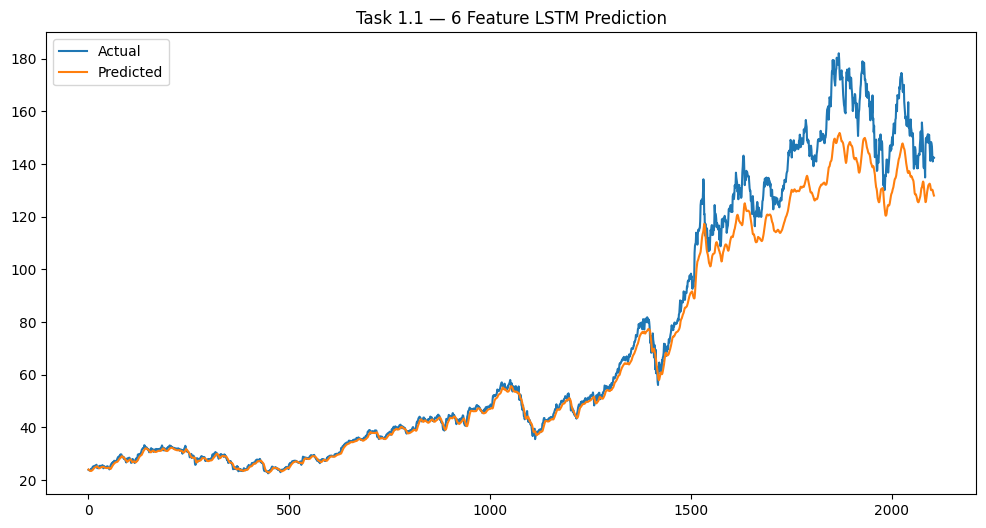

In [12]:
plt.figure(figsize=(12,6))
plt.plot(y_test_rescaled, label='Actual')
plt.plot(predictions_rescaled, label='Predicted')
plt.legend()
plt.title('Task 1.1 — 6 Feature LSTM Prediction')
plt.show()

In [13]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test_rescaled, predictions_rescaled))
print("RMSE:", rmse)

RMSE: 9.408209405974128


### Task 1.2 Nasdaq 𝑘th day forecast 

In [14]:
def run_k_prediction(df, k, time_steps=60):
    from sklearn.preprocessing import MinMaxScaler
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense
    from sklearn.metrics import mean_squared_error
    import numpy as np

    # Features
    features = ['Open', 'High', 'Low', 'Close', 'Adjusted Close', 'Volume']

    # Data
    X_data = df[features].values
    y_data = df[['Close']].values

    # Scaling
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_scaled = scaler_X.fit_transform(X_data)
    y_scaled = scaler_y.fit_transform(y_data)

    # Create sequences
    X, y = [], []
    for i in range(time_steps, len(X_scaled) - k):
        X.append(X_scaled[i-time_steps:i])
        y.append(y_scaled[i + k])

    X = np.array(X)
    y = np.array(y)

    # Split
    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    # Model
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(X.shape[1], X.shape[2])),
        LSTM(32),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse')

    # Train
    model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)

    # Predict
    predictions = model.predict(X_test)

    # Inverse transform
    predictions_rescaled = scaler_y.inverse_transform(predictions)
    y_test_rescaled = scaler_y.inverse_transform(y_test)

    # RMSE
    rmse = np.sqrt(mean_squared_error(y_test_rescaled, predictions_rescaled))

    return y_test_rescaled, predictions_rescaled, rmse

In [15]:
y_3, pred_3, rmse_3 = run_k_prediction(df, k=3)
y_7, pred_7, rmse_7 = run_k_prediction(df, k=7)

66/66 [==============================] - 1s 5ms/step


In [16]:
print("RMSE (k=3):", rmse_3)
print("RMSE (k=7):", rmse_7)

RMSE (k=3): 13.999033857661004
RMSE (k=7): 18.35492285395141


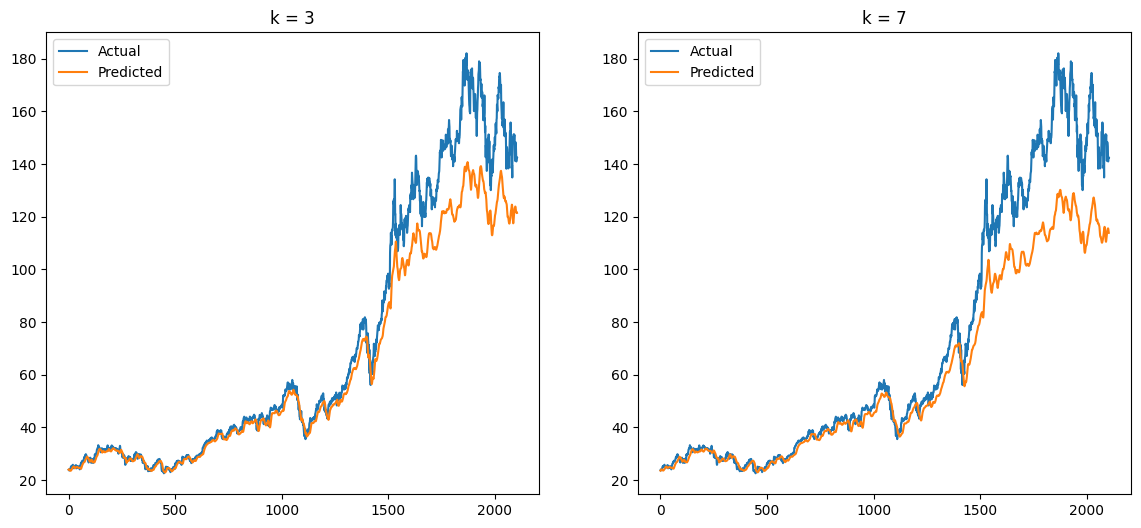

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.plot(y_3, label='Actual')
plt.plot(pred_3, label='Predicted')
plt.title('k = 3')
plt.legend()

plt.subplot(1,2,2)
plt.plot(y_7, label='Actual')
plt.plot(pred_7, label='Predicted')
plt.title('k = 7')
plt.legend()

plt.show()

### Task 1.3 Nasdaq 𝑘 days forecast

In [18]:
def run_multistep_prediction(df, k, time_steps=60):
    import numpy as np
    from sklearn.preprocessing import MinMaxScaler
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense
    from sklearn.metrics import mean_squared_error

    # Features
    features = ['Open', 'High', 'Low', 'Close', 'Adjusted Close', 'Volume']

    # Data
    X_data = df[features].values
    y_data = df[['Close']].values

    # Scaling
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_scaled = scaler_X.fit_transform(X_data)
    y_scaled = scaler_y.fit_transform(y_data)

    # Create sequences (multi-step)
    X, y = [], []
    for i in range(time_steps, len(X_scaled) - k):
        X.append(X_scaled[i-time_steps:i])
        y.append(y_scaled[i:i+k].flatten())

    X = np.array(X)
    y = np.array(y)

    # Split
    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    # Model
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(X.shape[1], X.shape[2])),
        LSTM(32),
        Dense(k)
    ])

    model.compile(optimizer='adam', loss='mse')

    # Train
    model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)

    # Predict
    predictions = model.predict(X_test)

    # Inverse transform
    pred_flat = predictions.reshape(-1, 1)
    y_flat = y_test.reshape(-1, 1)

    pred_rescaled = scaler_y.inverse_transform(pred_flat)
    y_rescaled = scaler_y.inverse_transform(y_flat)

    predictions_rescaled = pred_rescaled.reshape(predictions.shape)
    y_test_rescaled = y_rescaled.reshape(y_test.shape)

    # RMSE per step
    rmses = []
    for step in range(k):
        rmse = np.sqrt(mean_squared_error(
            y_test_rescaled[:, step],
            predictions_rescaled[:, step]
        ))
        rmses.append(rmse)

    return y_test_rescaled, predictions_rescaled, rmses

In [19]:
y_3, pred_3, rmse_3 = run_multistep_prediction(df, k=3)
y_7, pred_7, rmse_7 = run_multistep_prediction(df, k=7)

66/66 [==============================] - 1s 5ms/step


In [20]:
print("RMSE per step (k=3):", rmse_3)
print("RMSE per step (k=7):", rmse_7)

RMSE per step (k=3): [14.18922266700871, 14.06472622682202, 14.93395046555115]
RMSE per step (k=7): [14.051720872100727, 17.01957187436576, 21.476647055886247, 18.20263092242256, 21.457587261248285, 20.85121698611101, 20.309937369753097]


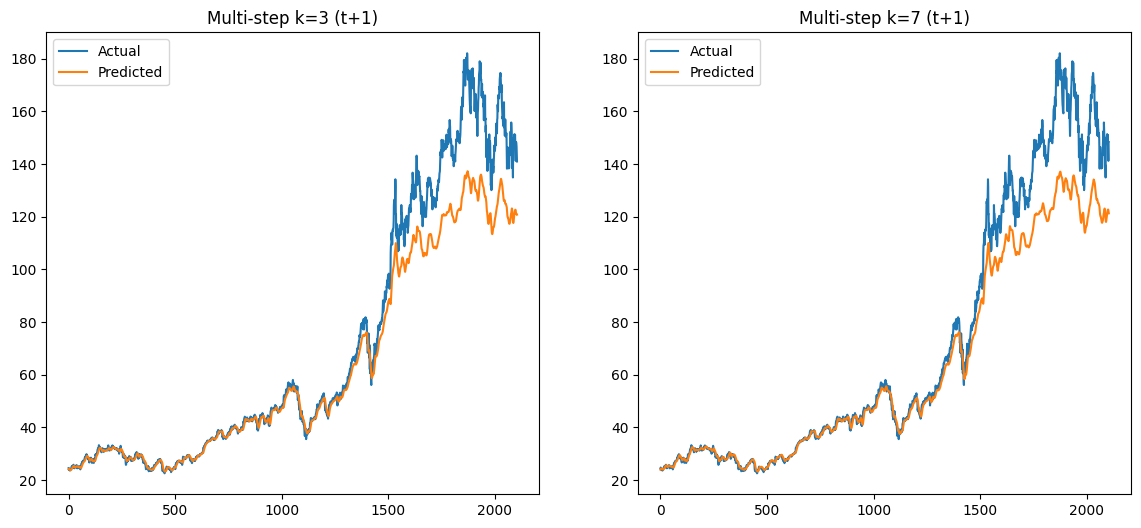

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.plot(y_3[:,0], label='Actual')
plt.plot(pred_3[:,0], label='Predicted')
plt.title('Multi-step k=3 (t+1)')
plt.legend()

plt.subplot(1,2,2)
plt.plot(y_7[:,0], label='Actual')
plt.plot(pred_7[:,0], label='Predicted')
plt.title('Multi-step k=7 (t+1)')
plt.legend()

plt.show()

## Task 2 - Vietnam stock price prediction (Vietnam dataset)

### Task 2.1 Vietnam multi-feature extension 

In [22]:
import os 
print(os.listdir('data-vn-20230228'))
print(os.listdir('data-vn-20230228/stock-historical-data'))

['dividend-history', '.DS_Store', 'ticker-overview.csv', 'crawl-vn-data.ipynb', 'companies.csv', 'financial-ratio', 'industry-analysis', 'stock-historical-data']
['VDP-VNINDEX-History.csv', 'NCT-VNINDEX-History.csv', 'SSB-VNINDEX-History.csv', 'AAM-VNINDEX-History.csv', 'PET-VNINDEX-History.csv', 'SVC-VNINDEX-History.csv', 'FIT-VNINDEX-History.csv', 'HHN-UpcomIndex-History.csv', 'QBS-VNINDEX-History.csv', 'FBA-UpcomIndex-History.csv', 'NOS-UpcomIndex-History.csv', 'CTD-VNINDEX-History.csv', 'VDT-UpcomIndex-History.csv', 'L35-HNXIndex-History.csv', 'HDO-UpcomIndex-History.csv', 'MDG-VNINDEX-History.csv', 'CMM-UpcomIndex-History.csv', 'APH-VNINDEX-History.csv', 'HIZ-UpcomIndex-History.csv', 'NHV-UpcomIndex-History.csv', 'VTG-UpcomIndex-History.csv', 'CTX-HNXIndex-History.csv', 'TMW-UpcomIndex-History.csv', 'TSB-HNXIndex-History.csv', 'A32-UpcomIndex-History.csv', 'SHS-HNXIndex-History.csv', 'NDW-UpcomIndex-History.csv', 'SB1-UpcomIndex-History.csv', 'NNG-UpcomIndex-History.csv', 'BT1-Upc

In [23]:
import pandas as pd

df = pd.read_csv('data-vn-20230228/stock-historical-data/ACG-VNINDEX-History.csv')
df.head()

,Unnamed: 0,Open,High,Low,Close,Volume,TradingDate
0,0,76287.0,76287.0,62362.0,74600.0,197900,2021-08-04
1,1,76226.0,76226.0,68477.0,70800.0,227117,2021-08-05
2,2,71443.0,71443.0,69324.0,70900.0,155200,2021-08-06
3,3,69627.0,70232.0,65389.0,67400.0,135600,2021-08-09
4,4,67326.0,67447.0,65449.0,66900.0,133906,2021-08-10


In [24]:
print(df.columns)

Index(['Unnamed: 0', 'Open', 'High', 'Low', 'Close', 'Volume', 'TradingDate'], dtype='object')


In [25]:
# Drop useless column
df = df.drop(columns=['Unnamed: 0'])

# Fix date column
df['TradingDate'] = pd.to_datetime(df['TradingDate'])
df = df.sort_values('TradingDate')
df.set_index('TradingDate', inplace=True)

df.head()

,Open,High,Low,Close,Volume
TradingDate,,,,,
2021-08-04,76287.0,76287.0,62362.0,74600.0,197900
2021-08-05,76226.0,76226.0,68477.0,70800.0,227117
2021-08-06,71443.0,71443.0,69324.0,70900.0,155200
2021-08-09,69627.0,70232.0,65389.0,67400.0,135600
2021-08-10,67326.0,67447.0,65449.0,66900.0,133906


In [26]:
features = ['Open', 'High', 'Low', 'Close', 'Volume']

In [27]:
import numpy as np

X_data = df[features].values
y_data = df[['Close']].values

In [28]:
from sklearn.preprocessing import MinMaxScaler

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X_data)
y_scaled = scaler_y.fit_transform(y_data)

In [29]:
time_steps = 60

X = []
y = []

for i in range(time_steps, len(X_scaled)):
    X.append(X_scaled[i-time_steps:i])
    y.append(y_scaled[i])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(323, 60, 5)
(323, 1)


In [30]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
y_train = y[:train_size]

X_test = X[train_size:]
y_test = y[train_size:]

In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X.shape[1], X.shape[2])),
    LSTM(32),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_10 (LSTM)              (None, 60, 64)            17920     
                                                                 
 lstm_11 (LSTM)              (None, 32)                12416     
                                                                 
 dense_5 (Dense)             (None, 1)                 33        
                                                                 
Total params: 30369 (118.63 KB)
Trainable params: 30369 (118.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [32]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
9/9 [==============================] - 2s 57ms/step - loss: 0.0737 - val_loss: 0.0088
Epoch 2/10
9/9 [==============================] - 0s 24ms/step - loss: 0.0208 - val_loss: 0.0101
Epoch 3/10
9/9 [==============================] - 0s 22ms/step - loss: 0.0101 - val_loss: 0.0088
Epoch 4/10
9/9 [==============================] - 0s 21ms/step - loss: 0.0081 - val_loss: 0.0062
Epoch 5/10
9/9 [==============================] - 0s 21ms/step - loss: 0.0070 - val_loss: 0.0055
Epoch 6/10
9/9 [==============================] - 0s 21ms/step - loss: 0.0063 - val_loss: 0.0038
Epoch 7/10
9/9 [==============================] - 0s 21ms/step - loss: 0.0054 - val_loss: 0.0035
Epoch 8/10
9/9 [==============================] - 0s 21ms/step - loss: 0.0047 - val_loss: 0.0032
Epoch 9/10
9/9 [==============================] - 0s 25ms/step - loss: 0.0042 - val_loss: 0.0031
Epoch 10/10
9/9 [==============================] - 0s 21ms/step - loss: 0.0038 - val_loss: 0.0037


In [33]:
predictions = model.predict(X_test)

3/3 [==============================] - 0s 4ms/step


In [34]:
predictions_rescaled = scaler_y.inverse_transform(predictions)
y_test_rescaled = scaler_y.inverse_transform(y_test)

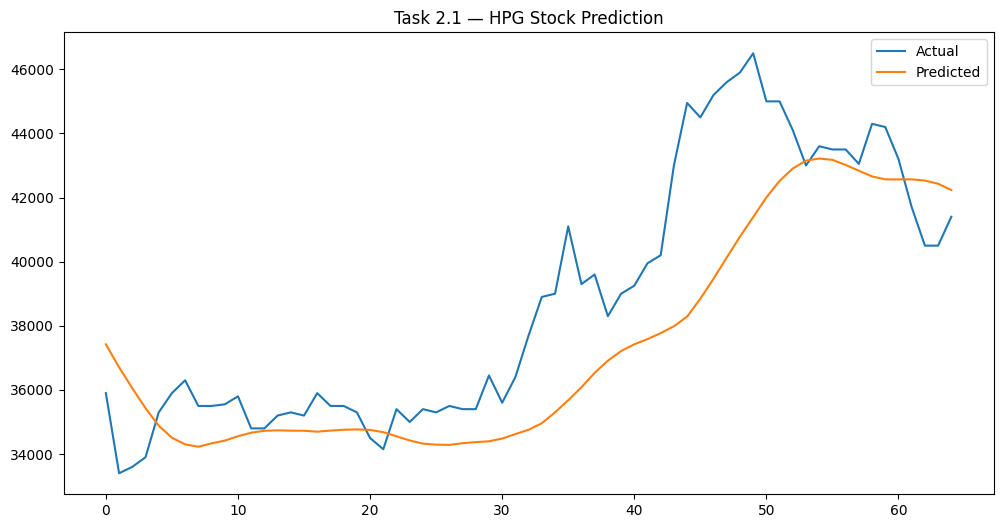

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y_test_rescaled, label='Actual')
plt.plot(predictions_rescaled, label='Predicted')
plt.legend()
plt.title('Task 2.1 — HPG Stock Prediction')
plt.show()

In [36]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test_rescaled, predictions_rescaled))
print("RMSE:", rmse)

RMSE: 2508.000683589445


### Task 2.2 Vietnam 𝑘th day forecast 

In [37]:
def run_k_prediction_vn(df, k, time_steps=60):
    import numpy as np
    from sklearn.preprocessing import MinMaxScaler
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense
    from sklearn.metrics import mean_squared_error

    # Features (Vietnam dataset)
    features = ['Open', 'High', 'Low', 'Close', 'Volume']

    # Data
    X_data = df[features].values
    y_data = df[['Close']].values

    # Scaling
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_scaled = scaler_X.fit_transform(X_data)
    y_scaled = scaler_y.fit_transform(y_data)

    # Create sequences (k-step ahead)
    X, y = [], []
    for i in range(time_steps, len(X_scaled) - k):
        X.append(X_scaled[i-time_steps:i])
        y.append(y_scaled[i + k])

    X = np.array(X)
    y = np.array(y)

    # Split
    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    # Model
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(X.shape[1], X.shape[2])),
        LSTM(32),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse')

    # Train
    model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)

    # Predict
    predictions = model.predict(X_test)

    # Inverse transform
    predictions_rescaled = scaler_y.inverse_transform(predictions)
    y_test_rescaled = scaler_y.inverse_transform(y_test)

    # RMSE
    rmse = np.sqrt(mean_squared_error(y_test_rescaled, predictions_rescaled))

    return y_test_rescaled, predictions_rescaled, rmse

In [38]:
y_3, pred_3, rmse_3 = run_k_prediction_vn(df, k=3)
y_7, pred_7, rmse_7 = run_k_prediction_vn(df, k=7)

2/2 [==============================] - 0s 6ms/step


In [39]:
print("RMSE (k=3):", rmse_3)
print("RMSE (k=7):", rmse_7)

RMSE (k=3): 3370.582044556093
RMSE (k=7): 4395.290658810292


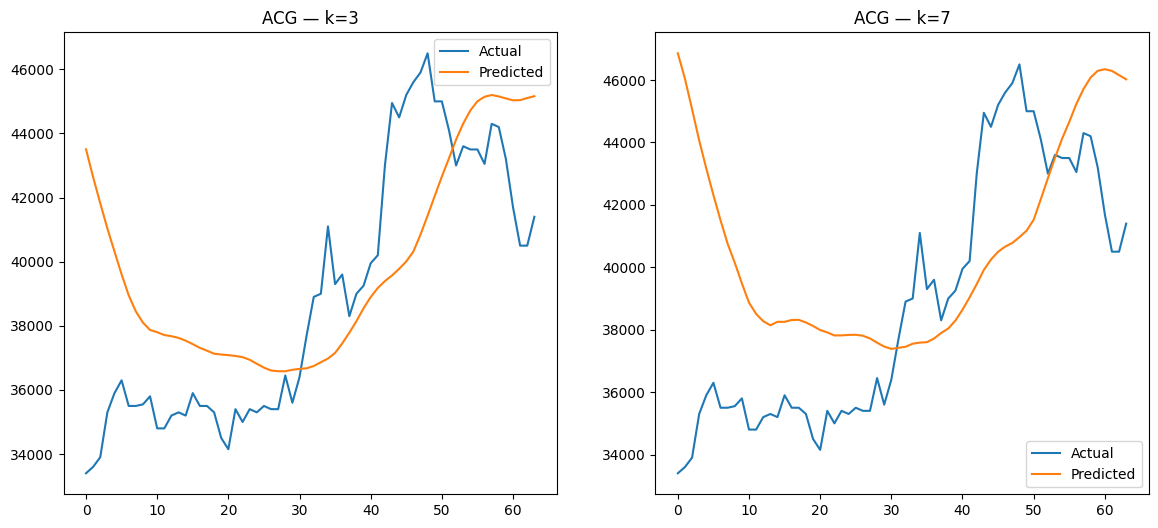

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.plot(y_3, label='Actual')
plt.plot(pred_3, label='Predicted')
plt.title('ACG — k=3')
plt.legend()

plt.subplot(1,2,2)
plt.plot(y_7, label='Actual')
plt.plot(pred_7, label='Predicted')
plt.title('ACG — k=7')
plt.legend()

plt.show()

### Task 2.3 Vietnam 𝑘 days forecast

In [41]:
def run_multistep_prediction_vn(df, k, time_steps=60):
    import numpy as np
    from sklearn.preprocessing import MinMaxScaler
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense
    from sklearn.metrics import mean_squared_error

    # Features
    features = ['Open', 'High', 'Low', 'Close', 'Volume']

    # Data
    X_data = df[features].values
    y_data = df[['Close']].values

    # Scaling
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_scaled = scaler_X.fit_transform(X_data)
    y_scaled = scaler_y.fit_transform(y_data)

    # Create sequences (multi-step)
    X, y = [], []
    for i in range(time_steps, len(X_scaled) - k):
        X.append(X_scaled[i-time_steps:i])
        y.append(y_scaled[i:i+k].flatten())

    X = np.array(X)
    y = np.array(y)

    # Split
    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    # Model
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(X.shape[1], X.shape[2])),
        LSTM(32),
        Dense(k)   # 👈 multi-output
    ])

    model.compile(optimizer='adam', loss='mse')

    # Train
    model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)

    # Predict
    predictions = model.predict(X_test)

    # Inverse transform
    pred_flat = predictions.reshape(-1, 1)
    y_flat = y_test.reshape(-1, 1)

    pred_rescaled = scaler_y.inverse_transform(pred_flat)
    y_rescaled = scaler_y.inverse_transform(y_flat)

    predictions_rescaled = pred_rescaled.reshape(predictions.shape)
    y_test_rescaled = y_rescaled.reshape(y_test.shape)

    # RMSE per step
    rmses = []
    for step in range(k):
        rmse = np.sqrt(mean_squared_error(
            y_test_rescaled[:, step],
            predictions_rescaled[:, step]
        ))
        rmses.append(rmse)

    return y_test_rescaled, predictions_rescaled, rmses

In [42]:
y_3, pred_3, rmse_3 = run_multistep_prediction_vn(df, k=3)
y_7, pred_7, rmse_7 = run_multistep_prediction_vn(df, k=7)

2/2 [==============================] - 0s 6ms/step


In [43]:
print("RMSE per step (k=3):", rmse_3)
print("RMSE per step (k=7):", rmse_7)

RMSE per step (k=3): [4336.560194514812, 4012.1818885520943, 3556.3259673985276]
RMSE per step (k=7): [22118.605863973426, 18722.092145996696, 18735.783631423426, 20551.947041747408, 15661.676776949686, 16880.460319902486, 15130.94065687968]


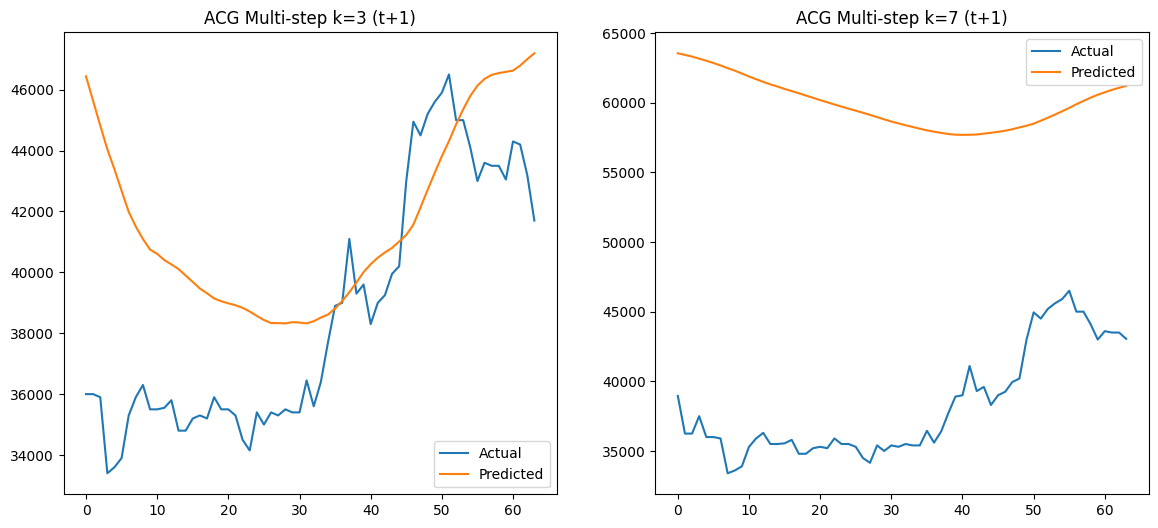

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.plot(y_3[:,0], label='Actual')
plt.plot(pred_3[:,0], label='Predicted')
plt.title('ACG Multi-step k=3 (t+1)')
plt.legend()

plt.subplot(1,2,2)
plt.plot(y_7[:,0], label='Actual')
plt.plot(pred_7[:,0], label='Predicted')
plt.title('ACG Multi-step k=7 (t+1)')
plt.legend()

plt.show()

## Task 3 - Trading signal identification for Vietnam market

### Task 3.1 Buying signal identification 

In [45]:
import numpy as np
import pandas as pd

# Load your ACG dataset
df = pd.read_csv('data-vn-20230228/stock-historical-data/ACG-VNINDEX-History.csv')

# Clean
df = df.drop(columns=['Unnamed: 0'])
df['TradingDate'] = pd.to_datetime(df['TradingDate'])
df = df.sort_values('TradingDate')
df.set_index('TradingDate', inplace=True)

features = ['Open', 'High', 'Low', 'Close', 'Volume']

In [46]:
def create_buy_labels(df, k=5, threshold=0.02):
    close = df['Close'].values
    labels = []

    for i in range(len(close) - k):
        current = close[i]
        future_max = max(close[i+1:i+1+k])

        # Buy if price increases at least 2%
        if (future_max - current) / current > threshold:
            labels.append(1)
        else:
            labels.append(0)

    return np.array(labels)

In [47]:
from sklearn.preprocessing import MinMaxScaler

time_steps = 60
k = 5  # future window

# Create labels
labels = create_buy_labels(df, k=k)

# Features
X_data = df[features].values[:-k]  # align with labels

# Scale
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_data)

In [48]:
X, y = [], []

for i in range(time_steps, len(X_scaled)):
    X.append(X_scaled[i-time_steps:i])
    y.append(labels[i])

X = np.array(X)
y = np.array(y)

print(X.shape, y.shape)

(318, 60, 5) (318,)


In [49]:
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [50]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X.shape[1], X.shape[2])),
    LSTM(32),
    Dense(1, activation='sigmoid')   # 👈 classification
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_20 (LSTM)              (None, 60, 64)            17920     
                                                                 
 lstm_21 (LSTM)              (None, 32)                12416     
                                                                 
 dense_10 (Dense)            (None, 1)                 33        
                                                                 
Total params: 30369 (118.63 KB)
Trainable params: 30369 (118.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [51]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
8/8 [==============================] - 2s 66ms/step - loss: 0.5925 - accuracy: 0.7362 - val_loss: 0.6869 - val_accuracy: 0.5156
Epoch 2/10
8/8 [==============================] - 0s 22ms/step - loss: 0.5333 - accuracy: 0.7835 - val_loss: 0.6911 - val_accuracy: 0.5156
Epoch 3/10
8/8 [==============================] - 0s 21ms/step - loss: 0.5255 - accuracy: 0.7835 - val_loss: 0.6868 - val_accuracy: 0.5156
Epoch 4/10
8/8 [==============================] - 0s 21ms/step - loss: 0.5245 - accuracy: 0.7835 - val_loss: 0.6879 - val_accuracy: 0.5156
Epoch 5/10
8/8 [==============================] - 0s 36ms/step - loss: 0.5222 - accuracy: 0.7835 - val_loss: 0.6903 - val_accuracy: 0.5156
Epoch 6/10
8/8 [==============================] - 0s 28ms/step - loss: 0.5226 - accuracy: 0.7835 - val_loss: 0.6900 - val_accuracy: 0.5156
Epoch 7/10
8/8 [==============================] - 0s 24ms/step - loss: 0.5239 - accuracy: 0.7835 - val_loss: 0.6881 - val_accuracy: 0.5156
Epoch 8/10
8/8 [===========

In [52]:
pred_probs = model.predict(X_test)
pred_labels = (pred_probs > 0.42).astype(int)

2/2 [==============================] - 0s 7ms/step


In [53]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, pred_labels))
print(classification_report(y_test, pred_labels))

Accuracy: 0.578125
              precision    recall  f1-score   support

           0       0.62      0.45      0.53        33
           1       0.55      0.71      0.62        31

    accuracy                           0.58        64
   macro avg       0.59      0.58      0.57        64
weighted avg       0.59      0.58      0.57        64



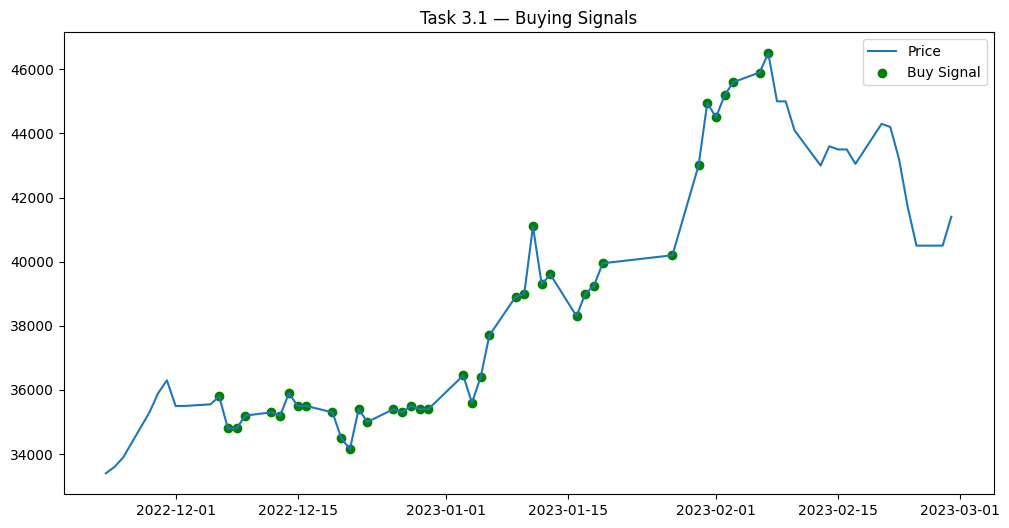

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df.index[-len(y_test):], df['Close'].values[-len(y_test):], label='Price')

# mark BUY signals
buy_points = np.where(pred_labels.flatten() == 1)[0]
plt.scatter(
    df.index[-len(y_test):][buy_points],
    df['Close'].values[-len(y_test):][buy_points],
    color='green', label='Buy Signal'
)

plt.legend()
plt.title('Task 3.1 — Buying Signals')
plt.show()

### Task 3.2 Selling signal identification 

In [55]:
def create_sell_labels(df, k=5, threshold=0.05):
    close = df['Close'].values
    labels = []

    for i in range(len(close) - k):
        current = close[i]
        future_min = min(close[i+1:i+1+k])

        # SELL if price drops at least 2%
        if (current - future_min) / current > threshold:
            labels.append(1)
        else:
            labels.append(0)

    return np.array(labels)

In [56]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

time_steps = 60
k = 5

# Create labels
labels = create_sell_labels(df, k=k, threshold=0.02)

# Features
features = ['Open', 'High', 'Low', 'Close', 'Volume']
X_data = df[features].values[:-k]

# Scale
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_data)

In [57]:
X, y = [], []

for i in range(time_steps, len(X_scaled)):
    X.append(X_scaled[i-time_steps:i])
    y.append(labels[i])

X = np.array(X)
y = np.array(y)

In [58]:
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [59]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X.shape[1], X.shape[2])),
    LSTM(32),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [60]:
model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
8/8 [==============================] - 2s 119ms/step - loss: 0.6243 - accuracy: 0.6496 - val_loss: 0.6979 - val_accuracy: 0.5938
Epoch 2/10
8/8 [==============================] - 0s 31ms/step - loss: 0.5912 - accuracy: 0.7165 - val_loss: 0.6963 - val_accuracy: 0.5938
Epoch 3/10
8/8 [==============================] - 0s 28ms/step - loss: 0.5856 - accuracy: 0.7165 - val_loss: 0.6950 - val_accuracy: 0.5938
Epoch 4/10
8/8 [==============================] - 0s 51ms/step - loss: 0.5861 - accuracy: 0.7165 - val_loss: 0.6967 - val_accuracy: 0.5938
Epoch 5/10
8/8 [==============================] - 0s 26ms/step - loss: 0.5829 - accuracy: 0.7165 - val_loss: 0.6995 - val_accuracy: 0.5938
Epoch 6/10
8/8 [==============================] - 0s 26ms/step - loss: 0.5847 - accuracy: 0.7165 - val_loss: 0.6990 - val_accuracy: 0.5938
Epoch 7/10
8/8 [==============================] - 0s 28ms/step - loss: 0.5767 - accuracy: 0.7165 - val_loss: 0.7010 - val_accuracy: 0.5938
Epoch 8/10
8/8 [==========

In [61]:
pred_probs = model.predict(X_test)

# slightly relaxed threshold
pred_labels = (pred_probs > 0.49).astype(int)

2/2 [==============================] - 1s 46ms/step


In [62]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, pred_labels))
print(classification_report(y_test, pred_labels))

Accuracy: 0.4375
              precision    recall  f1-score   support

           0       0.52      0.61      0.56        38
           1       0.25      0.19      0.22        26

    accuracy                           0.44        64
   macro avg       0.39      0.40      0.39        64
weighted avg       0.41      0.44      0.42        64



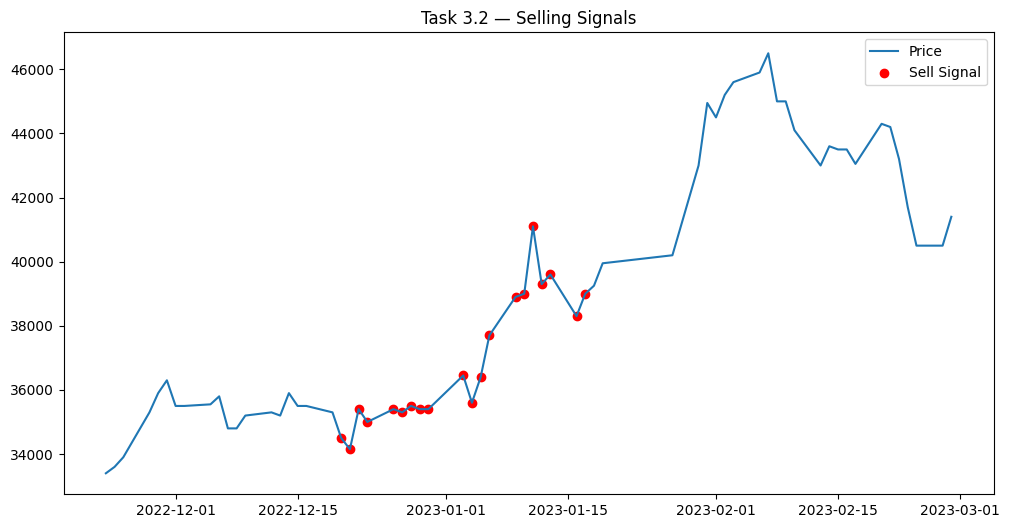

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

prices = df['Close'].values[-len(y_test):]
dates = df.index[-len(y_test):]

plt.plot(dates, prices, label='Price')

# SELL points
sell_points = np.where(pred_labels.flatten() == 1)[0]

plt.scatter(
    dates[sell_points],
    prices[sell_points],
    color='red',
    label='Sell Signal'
)

plt.legend()
plt.title('Task 3.2 — Selling Signals')
plt.show()

## Task 4 - Portfolio composition, risk management and portfolio optimization for Vietnam marke

### Task 4.1 Portfolio composition 

Any NaN in data_scaled: False
Epoch 1/10
80/80 [==============================] - 4s 26ms/step - loss: 0.0362 - val_loss: 0.3739
Epoch 2/10
80/80 [==============================] - 2s 23ms/step - loss: 0.0066 - val_loss: 0.1046
Epoch 3/10
80/80 [==============================] - 2s 25ms/step - loss: 0.0050 - val_loss: 0.0548
Epoch 4/10
80/80 [==============================] - 2s 22ms/step - loss: 0.0046 - val_loss: 0.1071
Epoch 5/10
80/80 [==============================] - 2s 23ms/step - loss: 0.0037 - val_loss: 0.0815
Epoch 6/10
80/80 [==============================] - 2s 22ms/step - loss: 0.0036 - val_loss: 0.1143
Epoch 7/10
80/80 [==============================] - 2s 23ms/step - loss: 0.0033 - val_loss: 0.1140
Epoch 8/10
80/80 [==============================] - 2s 23ms/step - loss: 0.0030 - val_loss: 0.0820
Epoch 9/10
80/80 [==============================] - 2s 23ms/step - loss: 0.0028 - val_loss: 0.1309
Epoch 10/10
80/80 [==============================] - 2s 23ms/step - loss: 0.002

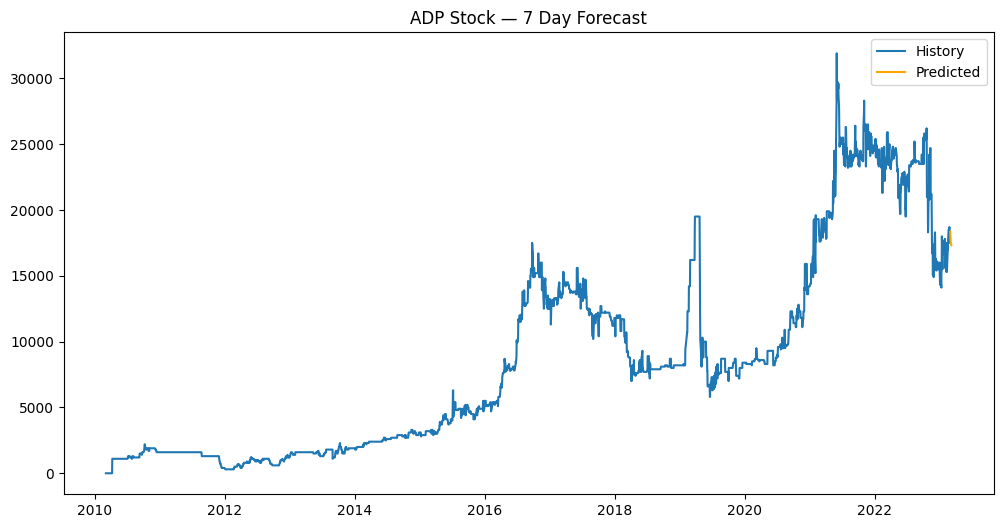

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

df = pd.read_csv('data-vn-20230228/stock-historical-data/ADP-UpcomIndex-History.csv')

df['Date'] = pd.to_datetime(df['TradingDate'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

features = ['Open', 'High', 'Low', 'Close', 'Volume']

df = df[features].dropna()

scaler = StandardScaler()
data_scaled = scaler.fit_transform(df)

print("Any NaN in data_scaled:", np.isnan(data_scaled).any())


time_steps = 60

X = []
y = []

close_idx = features.index('Close')

for i in range(time_steps, len(data_scaled)):
    X.append(data_scaled[i-time_steps:i])
    y.append(data_scaled[i, close_idx])

X, y = np.array(X), np.array(y)


train_size = int(len(X) * 0.8)

X_train = X[:train_size]
y_train = y[:train_size]

X_test = X[train_size:]
y_test = y[train_size:]

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X.shape[1], X.shape[2])),
    LSTM(32),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

future_steps = 7

last_sequence = X[-1]
future_preds = []

current_input = last_sequence.copy()

for _ in range(future_steps):
    pred = model.predict(current_input.reshape(1, time_steps, len(features)), verbose=0)[0, 0]

    pred = np.clip(pred, -3, 3)

    future_preds.append(pred)

    new_row = current_input[-1].copy()
    new_row[close_idx] = pred

    current_input = np.vstack([current_input[1:], new_row])

dummy = np.zeros((future_steps, len(features)))
dummy[:, close_idx] = future_preds

future_prices = scaler.inverse_transform(dummy)[:, close_idx]

current_price = df['Close'].iloc[-1]
predicted_price = future_prices[-1]

return_pct = (predicted_price - current_price) / current_price * 100

print("Current price:", current_price)
print("Predicted price (7 days):", predicted_price)
print("Expected return (%):", return_pct)

if return_pct > 0:
    print("PROFITABLE STOCK")
else:
    print("NOT PROFITABLE")

plt.figure(figsize=(12,6))

plt.plot(df.index, df['Close'], label='History')

future_dates = pd.date_range(start=df.index[-1], periods=future_steps+1)[1:]
plt.plot(future_dates, future_prices, label='Predicted', color='orange')

plt.title('ADP Stock — 7 Day Forecast')
plt.legend()
plt.show()

### Task 4.2 Risk management 

In [65]:
import numpy as np
import pandas as pd

def predict_return(file_path):
    from sklearn.preprocessing import StandardScaler
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense

    df = pd.read_csv(file_path)

    # Fix date
    df['Date'] = pd.to_datetime(df['TradingDate'])
    df = df.sort_values('Date')
    df.set_index('Date', inplace=True)

    # Fix numeric columns 
    for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    features = ['Open', 'High', 'Low', 'Close', 'Volume']
    df = df[features].dropna()

    # Scaling
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(df)

    # Create sequences
    time_steps = 60
    X, y = [], []
    close_idx = features.index('Close')

    for i in range(time_steps, len(data_scaled)):
        X.append(data_scaled[i-time_steps:i])
        y.append(data_scaled[i, close_idx])

    X, y = np.array(X), np.array(y)

    # Train split
    split = int(len(X) * 0.8)
    X_train, y_train = X[:split], y[:split]

    # Model
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(X.shape[1], X.shape[2])),
        LSTM(32),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse')

    model.fit(
        X_train, y_train,
        epochs=15,                
        batch_size=32,
        validation_split=0.1,
        verbose=0
    )

    future_steps = 7
    current_input = X[-1]
    preds = []

    for _ in range(future_steps):
        pred = model.predict(
            current_input.reshape(1, time_steps, len(features)),
            verbose=0
        )[0, 0]

        pred = np.clip(pred, -3, 3)
        preds.append(pred)

        new_row = current_input[-1].copy()
        new_row[close_idx] = pred
        current_input = np.vstack([current_input[1:], new_row])

    # Convert back to real price
    dummy = np.zeros((future_steps, len(features)))
    dummy[:, close_idx] = preds
    future_prices = scaler.inverse_transform(dummy)[:, close_idx]

    current_price = df['Close'].iloc[-1]
    predicted_price = future_prices[-1]

    return_pct = (predicted_price - current_price) / current_price * 100

    volatility = df['Close'].pct_change().dropna().std()
    # remove zero prices first
    clean_close = df['Close'][df['Close'] > 0]
    
    returns = clean_close.pct_change().dropna()
    
    returns = returns[np.abs(returns) < 0.5]
    
    volatility = returns.std()
    
    if np.isnan(volatility):
        volatility = 0

    return return_pct, volatility


def risk_score(return_pct, volatility):
    score = 0

    # Return risk
    if return_pct < -3:
        score += 3
    elif return_pct < 0:
        score += 2
    elif return_pct < 5:
        score += 1

    # Volatility risk
    if volatility > 0.04:
        score += 3
    elif volatility > 0.02:
        score += 2
    elif volatility > 0.01:
        score += 1

    return score


stocks = {
    "ADP": "data-vn-20230228/stock-historical-data/ADP-UpcomIndex-History.csv",
}

results = []

for name, path in stocks.items():
    print(f"\nProcessing {name}...")

    ret, vol = predict_return(path)
    score = risk_score(ret, vol)

    print(f"{name} → Return: {ret:.2f}%, Volatility: {vol:.4f}, Score: {score}")

    results.append({
        "Stock": name,
        "Return (%)": ret,
        "Volatility": vol,
        "Risk Score": score
    })


df_results = pd.DataFrame(results)

df_results = df_results.sort_values(by="Risk Score", ascending=False)

print("\n=== Risk Evaluation ===")
print(df_results)


risky_stocks = df_results[df_results["Risk Score"] >= 3]

print("\n=== High Risk Stocks (Exclude) ===")
print(risky_stocks)


Processing ADP...
ADP → Return: -5.57%, Volatility: 0.0414, Score: 6

=== Risk Evaluation ===
  Stock  Return (%)  Volatility  Risk Score
0   ADP   -5.569727    0.041414           6

=== High Risk Stocks (Exclude) ===
  Stock  Return (%)  Volatility  Risk Score
0   ADP   -5.569727    0.041414           6


### Task 4.3 Portfolio optimization 

In [66]:
import numpy as np
import pandas as pd

def predict_return_and_volatility(file_path):
    from sklearn.preprocessing import StandardScaler
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense
    from tensorflow.keras import backend as K

    df = pd.read_csv(file_path)

    df['Date'] = pd.to_datetime(df['TradingDate'])
    df = df.sort_values('Date')
    df.set_index('Date', inplace=True)

    for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    df = df[['Open', 'High', 'Low', 'Close', 'Volume']].dropna()

    if len(df) < 100:
        return 0, 0

    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(df)

    time_steps = 60
    X, y = [], []
    close_idx = 3

    for i in range(time_steps, len(data_scaled)):
        X.append(data_scaled[i-time_steps:i])
        y.append(data_scaled[i, close_idx])

    X, y = np.array(X), np.array(y)

    split = int(len(X) * 0.8)
    X_train, y_train = X[:split], y[:split]

    model = Sequential([
        LSTM(32, input_shape=(X.shape[1], X.shape[2])),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse')

    model.fit(
        X_train, y_train,
        epochs=3,          
        batch_size=64,
        verbose=0
    )

    future_steps = 7
    current_input = X[-1]
    preds = []

    for _ in range(future_steps):
        pred = model.predict(
            current_input.reshape(1, time_steps, 5),
            verbose=0
        )[0, 0]

        preds.append(pred)

        new_row = current_input[-1].copy()
        new_row[close_idx] = pred
        current_input = np.vstack([current_input[1:], new_row])

    dummy = np.zeros((future_steps, 5))
    dummy[:, close_idx] = preds
    future_prices = scaler.inverse_transform(dummy)[:, close_idx]

    current_price = df['Close'].iloc[-1]
    predicted_price = future_prices[-1]

    return_pct = (predicted_price - current_price) / current_price * 100
    

    clean_close = df['Close'][df['Close'] > 0]
    
    returns = clean_close.pct_change().dropna()
    
    returns = returns[np.abs(returns) < 0.3]
    
    if len(returns) > 0:
        volatility = returns.std()
    else:
        volatility = 0.01  
    
    if np.isnan(volatility):
        volatility = 0
        
    
    K.clear_session()
    
    
    return return_pct, volatility


stocks = {
    "ADP": "data-vn-20230228/stock-historical-data/ADP-UpcomIndex-History.csv",
}

results = []

for name, path in stocks.items():
    print(f"Processing {name}...")

    ret, vol = predict_return_and_volatility(path)

    print(f"{name} → Return: {ret:.2f}%, Volatility: {vol:.4f}")

    results.append({
        "Stock": name,
        "Return (%)": ret,
        "Volatility": vol
    })

df_results = pd.DataFrame(results)

df_filtered = df_results.sort_values(by="Return (%)", ascending=False).head(3)


df_filtered["Score"] = df_filtered["Return (%)"] / (df_filtered["Volatility"] + 1e-6)

if df_filtered["Score"].sum() == 0:
    df_filtered["Weight"] = 1 / len(df_filtered)
else:
    df_filtered["Weight"] = df_filtered["Score"] / df_filtered["Score"].sum()

print("\n=== Portfolio Allocation ===")
print(df_filtered)

portfolio_return = (df_filtered["Return (%)"] * df_filtered["Weight"]).sum()

print(f"\nExpected Portfolio Return: {portfolio_return:.2f}%")

Processing ADP...
ADP → Return: -3.53%, Volatility: 0.0400

=== Portfolio Allocation ===
  Stock  Return (%)  Volatility      Score  Weight
0   ADP   -3.530787    0.040037 -88.186567     1.0

Expected Portfolio Return: -3.53%


In [67]:
model.save("lstm_model.h5")

/Users/nguyenhavi/.pyenv/versions/3.8.18/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
